## Association Rule Learning (Apriori Algorithm) and Dimensionality Reduction (PCA)
## 24BAD099 - Rithish A


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

plt.style.use("seaborn-v0_8")

In [3]:
# 1) Load transactional dataset
file_path = r"d:\class materials AI&DS\sem 4\ML\Lab\EXP-8\Groceries_dataset.csv"
raw_df = pd.read_csv(file_path)

print("Shape:", raw_df.shape)
display(raw_df.head())
print("Columns:", list(raw_df.columns))

# 2) Build transaction list from available schema
# Common schema in this dataset: Member_number, Date, itemDescription
if {"Member_number", "Date", "itemDescription"}.issubset(raw_df.columns):
    txn_df = (
        raw_df.groupby(["Member_number", "Date"]) ["itemDescription"]
        .apply(list)
        .reset_index(name="Items")
    )
    transactions = txn_df["Items"].tolist()
elif {"Transaction", "Item"}.issubset(raw_df.columns):
    txn_df = raw_df.groupby("Transaction")["Item"].apply(list).reset_index(name="Items")
    transactions = txn_df["Items"].tolist()
else:
    # Fallback for two-column generic transactional data
    # Uses first column as transaction id and second column as item.
    c1, c2 = raw_df.columns[:2]
    txn_df = raw_df.groupby(c1)[c2].apply(list).reset_index(name="Items")
    transactions = txn_df["Items"].tolist()

print("Number of transactions:", len(transactions))
print("Sample transaction:", transactions[0][:10] if transactions else [])

Shape: (38765, 3)


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


Columns: ['Member_number', 'Date', 'itemDescription']
Number of transactions: 14963
Sample transaction: ['sausage', 'whole milk', 'semi-finished bread', 'yogurt']


In [7]:
# 3) Convert transactions to one-hot encoded matrix
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
one_hot_df = pd.DataFrame(te_array, columns=te.columns_)

print("One-hot shape:", one_hot_df.shape)
display(one_hot_df.head())

# 4,5) Generate frequent itemsets for multiple support thresholds
support_values = [0.01, 0.02, 0.03, 0.05]
itemset_summary = []
all_itemsets = {}

for s in support_values:
    fi = apriori(one_hot_df, min_support=s, use_colnames=True)
    fi["length"] = fi["itemsets"].apply(len)
    fi = fi.sort_values("support", ascending=False)
    all_itemsets[s] = fi
    itemset_summary.append({"min_support": s, "itemset_count": len(fi)})

summary_df = pd.DataFrame(itemset_summary)
print("Effect of support threshold on number of itemsets:")
display(summary_df)

# Choose a working threshold for rule generation
min_support = 0.01
freq_itemsets = all_itemsets[min_support].copy()
print(f"Frequent itemsets at min_support={min_support}: {len(freq_itemsets)}")
display(freq_itemsets.head(10))

One-hot shape: (14963, 167)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Effect of support threshold on number of itemsets:


,min_support,itemset_count
0,0.01,69
1,0.02,38
2,0.03,27
3,0.05,11


Frequent itemsets at min_support=0.01: 69


,support,itemsets,length
62,0.157923,(whole milk),1
40,0.122101,(other vegetables),1
46,0.110005,(rolls/buns),1
52,0.097106,(soda),1
63,0.085879,(yogurt),1
47,0.069572,(root vegetables),1
57,0.067767,(tropical fruit),1
5,0.060683,(bottled water),1
49,0.060349,(sausage),1
15,0.053131,(citrus fruit),1


In [9]:
# 6,7) Generate and filter association rules
rules = association_rules(freq_itemsets, metric="confidence", min_threshold=0.1)
rules = rules.sort_values(["lift", "confidence"], ascending=False)

print("Total generated rules:", len(rules))
display(rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(15))

# Compare rule count at different confidence levels
confidence_values = [0.1, 0.2, 0.3, 0.4]
conf_summary = []
for c in confidence_values:
    rf = rules[rules["confidence"] >= c]
    conf_summary.append({"min_confidence": c, "rule_count": len(rf)})

display(pd.DataFrame(conf_summary))

# Strong rules based on confidence + lift
strong_rules = rules.sort_values("lift", ascending=False).head(10).copy()
print("Strong rules (top 10 by lift):", len(strong_rules))
display(strong_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(20))

# Make rule sets readable for interpretation
for df in [rules, strong_rules]:
    if len(df) > 0:
        df["antecedents_str"] = df["antecedents"].apply(lambda x: ", ".join(sorted(list(x))))
        df["consequents_str"] = df["consequents"].apply(lambda x: ", ".join(sorted(list(x))))

print("Example interpretations:")
if len(strong_rules) > 0:
    for _, row in strong_rules.head(5).iterrows():
        print(
            f"If a basket contains [{row['antecedents_str']}], it tends to also contain "
            f"[{row['consequents_str']}] (support={row['support']:.3f}, "
            f"confidence={row['confidence']:.3f}, lift={row['lift']:.3f})."
        )
else:
    print("No strong rules at current thresholds; reduce thresholds to discover more rules.")

Total generated rules: 4


,antecedents,consequents,support,confidence,lift
3,(yogurt),(whole milk),0.011161,0.129961,0.822940
1,(rolls/buns),(whole milk),0.013968,0.126974,0.804028
0,(other vegetables),(whole milk),0.014837,0.121511,0.769430
2,(soda),(whole milk),0.011629,0.119752,0.758296


,min_confidence,rule_count
0,0.1,4
1,0.2,0
2,0.3,0
3,0.4,0


Strong rules (top 10 by lift): 4


,antecedents,consequents,support,confidence,lift
3,(yogurt),(whole milk),0.011161,0.129961,0.822940
1,(rolls/buns),(whole milk),0.013968,0.126974,0.804028
0,(other vegetables),(whole milk),0.014837,0.121511,0.769430
2,(soda),(whole milk),0.011629,0.119752,0.758296


Example interpretations:
If a basket contains [yogurt], it tends to also contain [whole milk] (support=0.011, confidence=0.130, lift=0.823).
If a basket contains [rolls/buns], it tends to also contain [whole milk] (support=0.014, confidence=0.127, lift=0.804).
If a basket contains [other vegetables], it tends to also contain [whole milk] (support=0.015, confidence=0.122, lift=0.769).
If a basket contains [soda], it tends to also contain [whole milk] (support=0.012, confidence=0.120, lift=0.758).


C:\Users\rithi\AppData\Local\Temp\ipykernel_12292\2898620544.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_len1, x="support", y="item", palette="viridis")


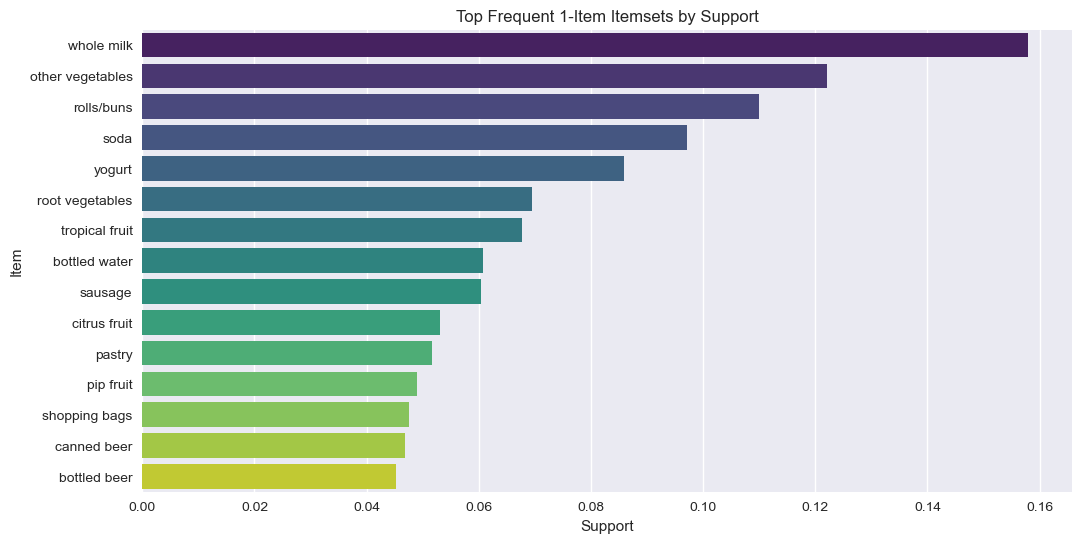

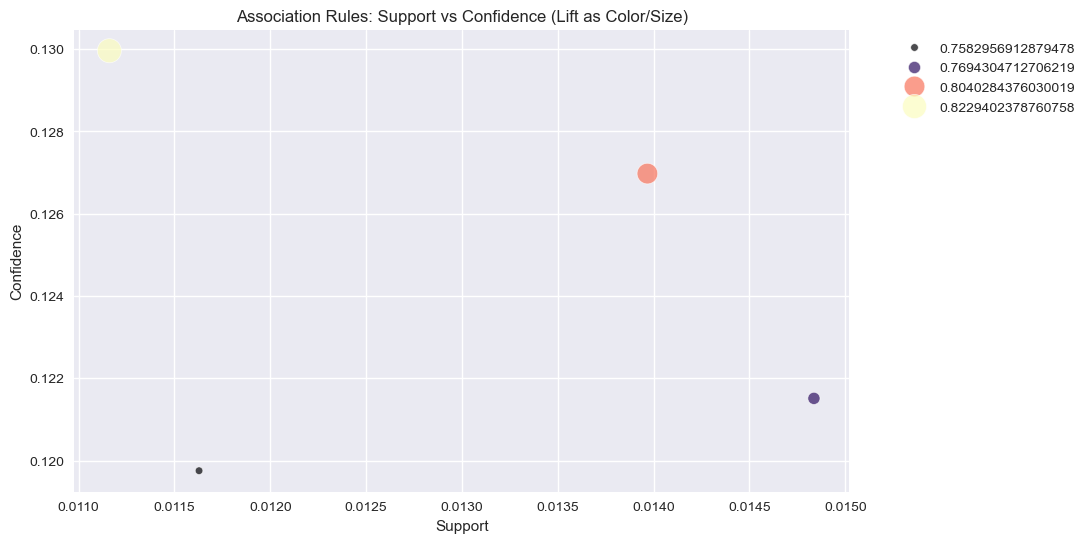

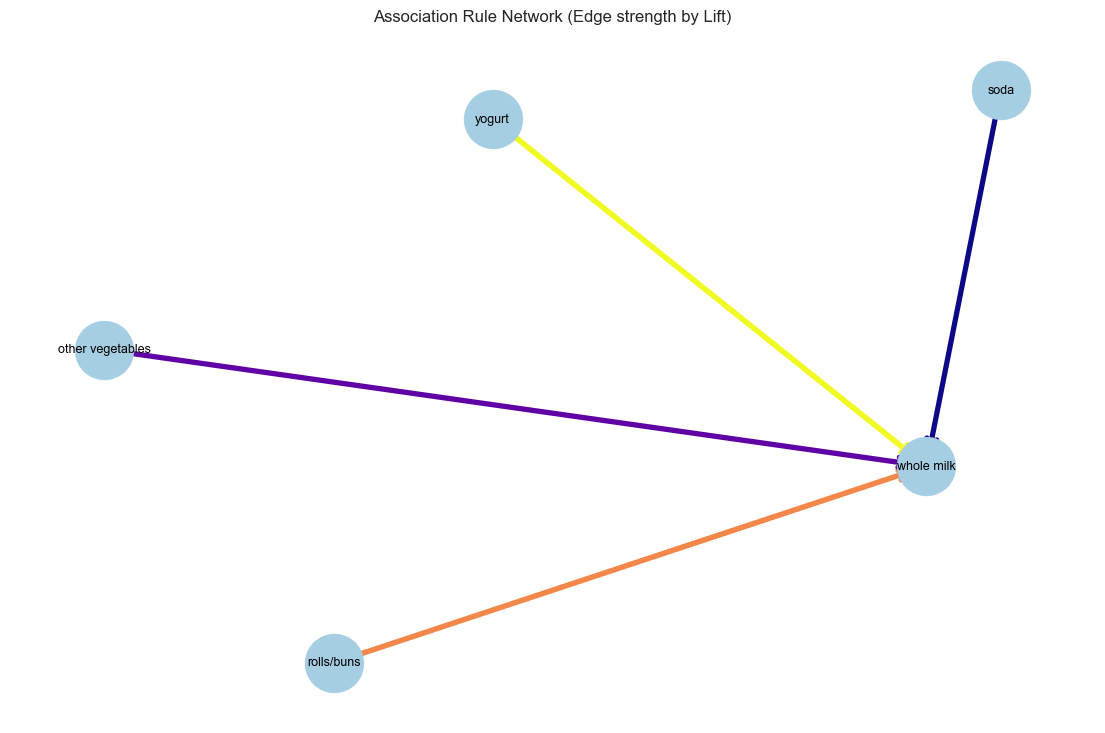

In [10]:
# 9) Visualizations for Scenario 1

# A) Bar chart of frequent single-item itemsets
fi_len1 = freq_itemsets[freq_itemsets["length"] == 1].copy()
fi_len1["item"] = fi_len1["itemsets"].apply(lambda x: list(x)[0])
fi_len1 = fi_len1.sort_values("support", ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=fi_len1, x="support", y="item", palette="viridis")
plt.title("Top Frequent 1-Item Itemsets by Support")
plt.xlabel("Support")
plt.ylabel("Item")
plt.show()

# B) Support vs confidence scatter (colored by lift)
plt.figure(figsize=(10, 6))
plot_df = rules.copy()
if len(plot_df) > 0:
    sns.scatterplot(
        data=plot_df,
        x="support",
        y="confidence",
        size="lift",
        hue="lift",
        sizes=(30, 300),
        palette="magma",
        alpha=0.7,
    )
    plt.title("Association Rules: Support vs Confidence (Lift as Color/Size)")
    plt.xlabel("Support")
    plt.ylabel("Confidence")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
else:
    plt.text(0.5, 0.5, "No rules to plot", ha="center", va="center")
plt.show()

# C) Network graph of top rules
top_n = 20
net_df = strong_rules.head(top_n) if len(strong_rules) > 0 else rules.head(top_n)
G = nx.DiGraph()

for _, row in net_df.iterrows():
    a = row.get("antecedents_str", ", ".join(sorted(list(row["antecedents"]))))
    c = row.get("consequents_str", ", ".join(sorted(list(row["consequents"]))))
    G.add_edge(a, c, weight=row["lift"], confidence=row["confidence"])

plt.figure(figsize=(14, 9))
if len(G.edges()) > 0:
    pos = nx.spring_layout(G, k=0.9, seed=42)
    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=1800, node_color="#A6CEE3")
    nx.draw_networkx_labels(G, pos, font_size=9)
    nx.draw_networkx_edges(
        G,
        pos,
        arrowstyle="->",
        arrowsize=18,
        width=[1 + (w / max(edge_weights)) * 3 for w in edge_weights],
        edge_color=edge_weights,
        edge_cmap=plt.cm.plasma,
    )
    plt.title("Association Rule Network (Edge strength by Lift)")
else:
    plt.text(0.5, 0.5, "No rules to build network", ha="center", va="center")
plt.axis("off")
plt.show()

In [11]:
# 10) Final summary and export
from pathlib import Path

output_dir = Path(file_path).parent

# Build compact summaries that are easy to inspect and submit
if 'freq_itemsets' in globals() and len(freq_itemsets) > 0:
    summary_itemsets = freq_itemsets.sort_values(['length', 'support'], ascending=[True, False]).copy()
    summary_itemsets['itemsets_str'] = summary_itemsets['itemsets'].apply(lambda x: ', '.join(sorted(list(x))))
    display(summary_itemsets[['support', 'length', 'itemsets_str']].head(10))
else:
    print('No frequent itemsets available to summarize.')

if 'rules' in globals() and len(rules) > 0:
    summary_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
    summary_rules['antecedents_str'] = summary_rules['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
    summary_rules['consequents_str'] = summary_rules['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
    display(summary_rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']].head(10))
else:
    print('No association rules available to summarize.')

# Save analysis outputs for reporting
if 'freq_itemsets' in globals():
    freq_itemsets.to_csv(output_dir / 'frequent_itemsets.csv', index=False)
if 'rules' in globals():
    rules.to_csv(output_dir / 'association_rules.csv', index=False)
if 'strong_rules' in globals():
    strong_rules.to_csv(output_dir / 'strong_rules.csv', index=False)

print(f'Analysis outputs saved to: {output_dir}')
print('Notebook analysis complete.')

,support,length,itemsets_str
62,0.157923,1,whole milk
40,0.122101,1,other vegetables
46,0.110005,1,rolls/buns
52,0.097106,1,soda
63,0.085879,1,yogurt
47,0.069572,1,root vegetables
57,0.067767,1,tropical fruit
5,0.060683,1,bottled water
49,0.060349,1,sausage
15,0.053131,1,citrus fruit


,antecedents_str,consequents_str,support,confidence,lift
3,yogurt,whole milk,0.011161,0.129961,0.822940
1,rolls/buns,whole milk,0.013968,0.126974,0.804028
0,other vegetables,whole milk,0.014837,0.121511,0.769430
2,soda,whole milk,0.011629,0.119752,0.758296


Analysis outputs saved to: d:\class materials AI&DS\sem 4\ML\Lab\EXP-8
Notebook analysis complete.
